# Kernel installation
- Run the following line (script) once, if the required kernel (`big-data-dda-kernel`) is not installed.
- You need to install this kernel only once

In [ ]:
!./install-kernel.sh

# Important!!!
Once the Kernel is installed,
1. Reload the notebook (reload/refresh the web page)
2. Select the kernel: Menu -> Kernel -> Change Kernel -> Select "dda-kernel"

Always use this kernel for upcoming exercises.

In [1]:
%matplotlib inline

In [2]:
# To enable horizontal scrolling
from IPython.display import display, HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))

# Initialisation of Spark Cluster and Environment

A typical workflow to use bigdata framework on HPC looks like below:

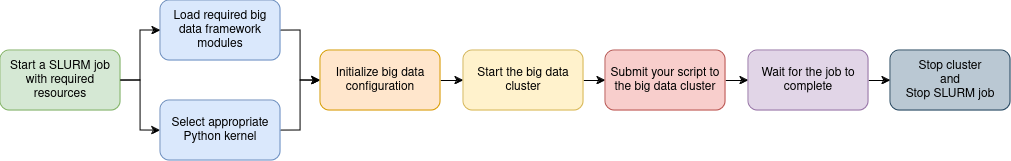

## Configuration files
Apache Spark uses certain configuration files to start a [standalone cluster](https://spark.apache.org/docs/latest/spark-standalone.html). These configuration files can be found and managed as follows:
- On Local machine:
    - On a local machine, you can find the configuration directory inside the `<Spark-Installation-Directory>/conf` directory.
- On ZIH HPC System:
    - On the ZIH HPC system, on JupyterHu infrastructure, the utility called **[BiJuTy](https://github.com/ScaDS/bijuty/tree/main)** is used to configure the environment. This utility helps in managing cluster lifecycle including configuration files.
        - Use following setup for the standalone cluster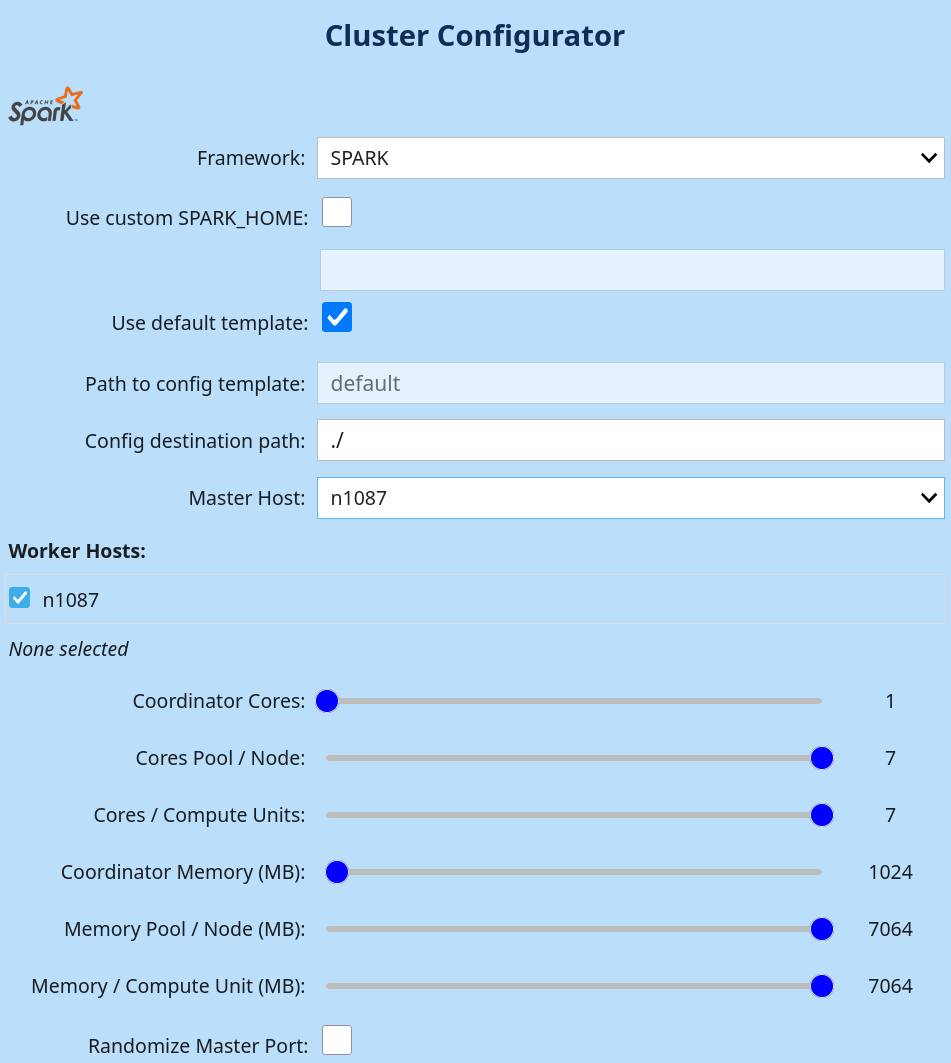
    - If you prefer using the command line interface (CLI), you can achieve the same setup using the information provided in the [HPC compendium](https://compendium.hpc.tu-dresden.de/software/big_data_frameworks/)

Once the configuration is initialized, you can edit it further as needed before starting the cluster.

## Cluster
Once the configuration is set up, you can start the Spark standalone cluster. The process involves initializing the master, worker, and driver processes, as well as the Spark context. Cluster is managed as follows:
- On Local machine:
    - The master and worker processes can be started using: `<Spark-Installation-Directory>/sbin/start-all.sh`
- On ZIH HPC System (JupyterHub):
    - The master and worker processes can be started by clicking: *Start Cluster* button in the dashboard. Wait untill you see a message stating "SPARK cluster started successfully" in the info box at the bottom of the dashboard utility.

Once the cluster processes are started, [Spark context](https://spark.apache.org/docs/3.5.1/api/python/reference/api/pyspark.SparkContext.html#pyspark.SparkContext) can be initialized. It is an entry point for Spark functionality, and is submitted to driver processes.

Note:
- In BiJuTy utility dashboard, mention full path in "Path to config" option.
- While initializing Spark context, do not forget to mention correct master hostname and port.

In [1]:
# Note: Skip if running on local machine
import bijuty

In [ ]:
from pyspark.sql import SparkSession
from pyspark import SparkContext
import re

spark = SparkSession.builder \
            .appName("WordOccurenceCountWithMobyDick") \
            .master("spark://MASTER_HOSTNAME:MASTER_PORT") \
            .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("WARN")

In [ ]:
print(f"Spark version: {sc.version}")
print(f"Spark master: {sc.master}")
print(f"Spark app name: {sc.appName}")

# Spark RDD and Transformations
Apache Spark uses RDD (Resilient Distributed Dataset) to perform operation on data. It is a fundamental data structure which is immutable and which can be distributed across multiple CPUs and nodes, to be processed in parallel.

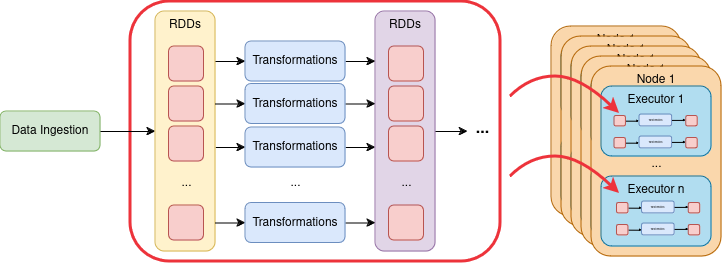

The transformations can be of many type. Currently Spark supports various [transformations](https://spark.apache.org/docs/latest/rdd-programming-guide.html#transformations) (like includeing map, filter, flatMap, groupBy, etc) and [actions](https://spark.apache.org/docs/latest/rdd-programming-guide.html#actions) (like collect, reduce, etc).

Download the text file and save it in your jupyter folder, so that the following statement works.

In [ ]:
linesRDD = sc.textFile("pg2701.txt")

# Concept of Lazy Computations
- Lazy computation is a key concept in Apache Spark's processing model. Spark delays the execution of transformations on data until an action is performed.
- When we apply transformations like `map` or `filter` as shown below, these operations are not executed immediately. Instead a logical plan of the mentioned transformations is created. Consider following example:
    ```python
    rdd = sc.parallelize([1, 2, 3, 4])
    transformed_rdd = rdd.map(lambda x: x * 2) # transformed_rdd is not computed right away
    ```
- It is the action operation that triggers the execution of above transformation and returns the value. Once the action operation is called, Spark checks the logical plan, optimizes it and then executes the necessary steps. Continuing above example:
    ```python
    result = transformed_rdd.collect() # The execution is triggered and stored in result
    ```
- This an important concept that helps running Apache Spark efficiently and in optimized way
- For more information:
    - [Apache Spark Documentation](https://spark.apache.org/docs/3.5.1/rdd-programming-guide.html#rdd-operations)
    - [https://blog.damavis.com/en/apache-spark-transformations-and-lazy-evaluation/](https://blog.damavis.com/en/apache-spark-transformations-and-lazy-evaluation/)
    - [Big data analytics on Apache Spark](https://link.springer.com/article/10.1007/s41060-016-0027-9)

# Exercise 1: Provide an overview over all chapters.
Note: the start of a chapter is a line that starts with "CHAPTER".

In [ ]:
# WHY: We need to filter the RDD to only include lines that start with "CHAPTER".
# WHAT: We use the filter() transformation on the RDD.
# HOW: A lambda function checks if each line starts with "CHAPTER " using the startswith() string method.
chaptersRDD = linesRDD.filter(lambda item: item.startswith('CHAPTER '))
chaptersRDD.collect()

In [ ]:
chaptersRDD = linesRDD.filter(lambda item: _______ )
chaptersRDD.collect()

# Exercise 2: Output each chapter with its corresponding first line number.

In [ ]:
# WHY: We need to extract the chapter number from the "CHAPTER X..." line.
# WHAT: We define a function to extract the number and use zipWithIndex() to get the line numbers of all lines, then filter for chapter lines.
# HOW: We use zipWithIndex() which returns (line_content, line_index), then filter for lines starting with "CHAPTER ". 
# Then we map these to extract just the chapter number and line index.

def getChapterNumber(line):
    """Reads the chapter number from a text line"""
    parts = line.split('.')
    if len(parts) > 0:
        chapter_str = parts[0].replace('CHAPTER ', '').strip()
        try:
            return int(chapter_str)
        except ValueError:
            pass
    return None

# Get lines with their line numbers: (line_text, line_number)
linesWithIndexRDD = linesRDD.zipWithIndex()

# Filter only chapter lines and map to (chapter_number, line_number)
chaptersWithStartLineNumbersRDD = linesWithIndexRDD.filter(lambda x: x[0].startswith('CHAPTER ')).map(lambda x: (getChapterNumber(x[0]), x[1])).filter(lambda x: x[0] is not None)

# Collect to the driver
lineToChapter = chaptersWithStartLineNumbersRDD.collect()
lineToChapter.sort(key=lambda x: x[0])
print(lineToChapter)

In [ ]:
def getChapterNumber(line):
    """Reads the chapter number from a text line by selecting the number after the word CHAPTER"""
    positionOfNumber = len("CHAPTER ")
    positionAfterNumber = line.find(".")
    numberString = line[positionOfNumber:positionAfterNumber]
    chapterNumber = int(numberString)
    return chapterNumber

In [ ]:
# chaptersWithStartLineNumbersRDD should contain tuples similar to ('Chapter 1. ...', 535)
chaptersWithStartLineNumbersRDD = linesRDD._______ #add something here...
chaptersWithStartLineNumbersRDD.take(2)

In [ ]:
# create an array that maps a chapter number (e. g. 1) to a line number (e. g. 535)
lineToChapter = [0]
lineToChapter += chaptersWithStartLineNumbersRDD \
                        .map(lambda item: _______ ) \ # Add something here
                        .collect()
print(lineToChapter)

# Exercise 3: Assign the chapter number to each line.

In [ ]:
# WHY: We need to associate every single word/line with its corresponding chapter for later grouping.
# WHAT: We broadcast the chapter-to-line-number mapping and use a map function to assign each line its chapter.
# HOW: We broadcast `lineToChapter` to all executors. Then we create a function that takes a line index and finds which chapter it belongs to by iterating through the broadcasted list.

# Broadcast the mapping to all executors
lineToChapterVar = sc.broadcast(lineToChapter)

def getChapterLineNumber(line_number):
    """Returns the chapter number for the given line number"""
    mapping = lineToChapterVar.value
    # Find the chapter whose start line is <= line_number, and the next chapter's start line is > line_number
    # The mapping is sorted by chapter number.
    current_chapter = 0 # 0 for text before chapter 1
    for chap_num, start_line in mapping:
        if line_number >= start_line:
            current_chapter = chap_num
        else:
            break
    return current_chapter

# Assign chapter number to each line: (chapter_number, line_text)
lineWithChapterRDD = linesWithIndexRDD.map(lambda x: (getChapterLineNumber(x[1]), x[0]))
lineWithChapterRDD.take(10)

In [ ]:
# make sure that the array 'lineToChapter' is available on each executor via 'lineVar'
lineVar = sc.broadcast(lineToChapter)

In [ ]:
def getChapterLineNumber(line_number):
    """Returns the chapter number for the given line number"""
    chapterLineNumbers = lineVar.value
    chapterNumber = 0
    for i in chapterLineNumbers:
        if int(i) <= int(line_number):
            chapterNumber = chapterLineNumbers.index(i)
        else:
            return chapterNumber
    return chapterNumber

In [ ]:
lineWithChapterRDD = linesRDD._______ #add something here...
lineWithChapterRDD.take(2)

# Exercise 4: Split each line into words. Remove numbers and signs. The result set should still contain the chapter number for each word.

In [ ]:
# WHY: We need to process the text to extract raw lowercase words for counting.
# WHAT: We use flatMap to split each line into multiple words, removing punctuation and converting to lowercase.
# HOW: We use the re module to split the text on non-alphanumeric characters, convert to lower(), and filter out empty strings. 
# flatMap ensures we get a flattened RDD of (word, chapter) tuples rather than lists of words.

import re

def process_line(chapter_line_tuple):
    chapter_num, line = chapter_line_tuple
    # Convert to lowercase and split by non-alphabetic characters
    words = re.split(r'[^a-zA-Z]+', line.lower())
    # Return list of (word, chapter_num) for non-empty words
    return [(word, chapter_num) for word in words if word]

# Apply flatMap to get one element per word
wordWithChapterRDD = lineWithChapterRDD.flatMap(process_line)
wordWithChapterRDD.take(10)

In [ ]:
# wordWithChapterRDD should contain tuples of the following form: (word, chapterId), e. g. ('The', 0)
wordWithChapterRDD = lineWithChapterRDD._______ #add something here...
wordWithChapterRDD.take(20)

# Exercise 5: Count the number of occurences of each word per chapter.

In [ ]:
# WHY: We want to aggregate the occurrences of each word within each chapter.
# WHAT: We use a map-reduce paradigm. Map each word to a count of 1, then reduce by key.
# HOW: The key is a tuple of (word, chapter_num). We map to ((word, chapter_num), 1), then use reduceByKey to sum the counts.

# Map to ((word, chapter), 1) and sum up the occurrences
wordOccurencePerChapterRDD = wordWithChapterRDD.map(lambda x: (x, 1)).reduceByKey(lambda a, b: a + b)
wordOccurencePerChapterRDD.take(10)

In [ ]:
# for simplicity, create an RDD with tuples of the form ((word, chapterId), count)
wordOccurencePerChapterRDD = wordWithChapterRDD._______ #add something here...
wordOccurencePerChapterRDD.take(3)

# Exercise 6: Create a plot of the ten most occuring words (per chapter) and their number of occurences.
Hint: Change the tuples in the `wordOccurencePerChapterRDD` from `((word, chapterId), count)` to `(chapterId, [(word, count)]`.

In [ ]:
# WHY: We want to visualize the top words to understand the text's composition per chapter.
# WHAT: We extract the top N words for each chapter, then use matplotlib to create bar charts.
# HOW: We filter the RDD for a specific chapter, sort by count descending, take the top elements, and plot them.

def getHighestWordOccurencesPerChapter(rdd, limit):
    """Return the most occurring words per chapter"""
    # Re-map to (chapter_num, (word, count)) then group by chapter
    # Or just return a local list for visualization
    # Sort by count descending
    sorted_rdd = rdd.sortBy(lambda x: x[1], ascending=False)
    return sorted_rdd.take(limit)

import matplotlib.pyplot as plt

def plotOccurences(chapter_data, chapter_number):
    # chapter_data is a list of ((word, chapter_number), count)
    words = [x[0][0] for x in chapter_data]
    counts = [x[1] for x in chapter_data]
    
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts, color='skyblue')
    plt.title(f'Top Words in Chapter {chapter_number}')
    plt.xlabel('Words')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

def plotOccurences_all_chapters(rdd, limit=10):
    # Get distinct chapters
    chapters = rdd.map(lambda x: x[0][1]).distinct().collect()
    chapters = sorted([c for c in chapters if c > 0]) # Exclude preamble
    
    for chap in chapters[:3]: # Plotting just first 3 chapters to avoid too many plots
        # Filter for the current chapter
        chap_rdd = rdd.filter(lambda x: x[0][1] == chap)
        top_words = getHighestWordOccurencesPerChapter(chap_rdd, limit)
        plotOccurences(top_words, chap)

# Plot for the first few chapters
plotOccurences_all_chapters(wordOccurencePerChapterRDD)

In [ ]:
def getHighestWordOccurencesPerChapter(rdd,limit):
    """Return the most occuring words of rdd as a new RDD, limit gives the number of items to return (per Chapter)"""
    return rdd._______ #add something here...
highestWordOccurencesPerChapterRDD = getHighestWordOccurencesPerChapter(wordOccurencePerChapterRDD,10)
occurencePerChapterMap = highestWordOccurencesPerChapterRDD.collectAsMap()

In [ ]:
import matplotlib.pyplot as plt
def plotOccurences(chapter_data, chapter_number):
    # Get the data for the specified chapter number
    if chapter_number not in chapter_data:
        print(f"Chapter {chapter_number} not found in the data.")
        return
    words, counts = zip(*chapter_data[chapter_number])
    
    # Plotting
    plt.figure(figsize=(10, 6))
    bars = plt.bar(words, counts, color='skyblue')
    plt.xlabel('Words')
    plt.ylabel('Counts')
    plt.title(f'Top 10 Highest Occurring Words in Chapter {chapter_number}')
    plt.xticks(rotation=45)

    # Adding the exact counts on top of the bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

plotOccurences(occurencePerChapterMap,0)

In [ ]:
def plotOccurences_all_chapters(chapter_data):
    num_chapters = len(chapter_data)
    
    # Determine the number of rows and columns for the subplots
    cols = 3  # Adjust this as needed
    rows = (num_chapters + cols - 1) // cols
    
    fig, axs = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axs = axs.flatten()  # Flatten to easily iterate over axs if it's a 2D array
    
    for idx, (chapter_number, word_data) in enumerate(chapter_data.items()):
        words, counts = zip(*word_data)
        bars = axs[idx].bar(words, counts, color='skyblue')
        axs[idx].set_xlabel('Words')
        axs[idx].set_ylabel('Counts')
        axs[idx].set_title(f'Top 10 Words in Chapter {chapter_number}')
        axs[idx].tick_params(axis='x', rotation=45)
        
        # Adding the exact counts on top of the bars
        for bar in bars:
            height = bar.get_height()
            axs[idx].text(bar.get_x() + bar.get_width() / 2.0, height, f'{height}', ha='center', va='bottom')
    
    # Hide any empty subplots if the number of chapters is less than rows*cols
    for ax in axs[num_chapters:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
plotOccurences_all_chapters(occurencePerChapterMap)

# Exercise 7: Remove stop words.
Note: Spark provides the class StopWordRemover for obtaining stop words.

In [ ]:
# WHY: Stop words (like "the", "and") carry little semantic meaning and dominate the counts, so they should be removed.
# WHAT: We use Spark MLlib's StopWordsRemover default list to filter out stop words.
# HOW: We broadcast the stop words array. Then we filter the wordOccurencePerChapterRDD to keep only words not in the broadcasted stop words list.

from pyspark.ml.feature import StopWordsRemover
# Get default English stop words
stop_words = StopWordsRemover.loadDefaultStopWords("english")
stopWordsVar = sc.broadcast(stop_words)

# Filter out the stop words
cleanedWordOccurencePerChapterRDD = wordOccurencePerChapterRDD.filter(lambda x: x[0][0] not in stopWordsVar.value)
cleanedWordOccurencePerChapterRDD.take(10)

In [ ]:
from pyspark.ml.feature import StopWordsRemover
stopWordsVar = sc.broadcast(StopWordsRemover.loadDefaultStopWords("english"))
cleanedWordWithChapterRDD = wordWithChapterRDD._______ #add something here...
cleanedWordWithChapterRDD.take(3)

In [ ]:
# structure should be the same as wordOccurencePerChapterRDD,
# so that we could reuse previously defined functions
cleanedWordOccurencePerChapterRDD = cleanedWordWithChapterRDD._______ #add something here...
cleanedWordOccurencePerChapterRDD.take(3)

# Exercise 8: Plot the occurences of words per chapter after stop word removal.

In [ ]:
# WHY: We want to see how the most frequent meaningful words change when stop words are ignored.
# WHAT: We plot the top words from the cleaned RDD.
# HOW: We simply pass the new `cleanedWordOccurencePerChapterRDD` to our existing plotting function.

def plotAll(rdd, limit):
    # Re-use the previously defined plotting function
    plotOccurences_all_chapters(rdd, limit)

# Plot top 10 meaningful words for the first 3 chapters
plotAll(cleanedWordOccurencePerChapterRDD, 10)

In [ ]:
def plotAll(rdd, limit):
    #add something here...

plotAll(cleanedWordOccurencePerChapterRDD,20)

# Stop Cluster and Job
- Once the work is completed,
    - Stop the Spark cluster: by clicking "Stop Cluster" button
    - Stop JupyterHub session: File (on top left of the browser) -> Hub Control Panel -> Stop My Server
 
